In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt
from multicam_tng.multicam2 import multicam_prediction
from scipy.stats import spearmanr


from scipy.stats import rankdata
from multicam_tng.utils import get_an_from_mpeak_mah
from astropy.table import Table


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [2]:
metadata = pd.read_csv(
    "../../data/tng300-1-table.csv"
)  # this ist just metadata which sims share
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [3]:
def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


In [ ]:
# -----------------------------
# Load data
# -----------------------------
# TODO: apply subhalo flag
hydro_raw = Table.read("../../data/hydro_final.ecsv")
len(hydro_raw)

101364

In [5]:
# Stellar mass cut
# NOTE: this cut can potentially bias the results so we avoid it
# although Ismael and Phil checked that it does not really matter.
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]

# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [6]:
# cut based on mpeak
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_full = hydro_raw[mpeak_cut_mask]
len(hydro_full)

11310

In [7]:
log10_mpeak = np.log10(hydro_full["mpeak"].data)
log10_stellar_mass = np.log10(hydro_full["stellar_mass"].data)

print(len(log10_mpeak), len(log10_stellar_mass))
assert len(log10_mpeak) == len(log10_stellar_mass)

# SHAM mean relation (NO scatter), also defines SHMR
logmstar_sham = qt(log10_mpeak, log10_stellar_mass)

11310 11310


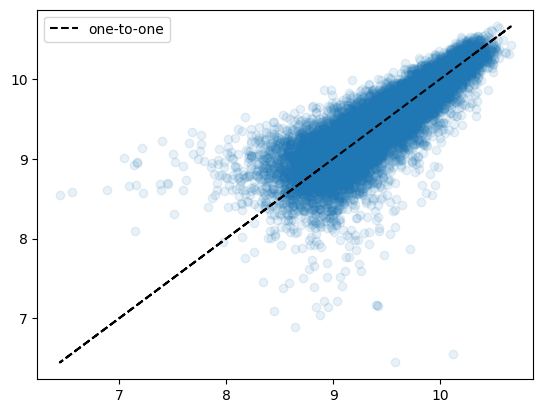

In [8]:
# what does the SHMR look like
plt.scatter(logmstar_sham, log10_stellar_mass, alpha=0.1)
plt.plot(log10_stellar_mass, log10_stellar_mass, ls="--", c="k", label="one-to-one")
plt.legend()

In [9]:
star_mask = (log10_stellar_mass > 9.5) & (log10_stellar_mass < 10.2)
hydro_mstar_cut = hydro_full[star_mask]

(array([  0.,   0.,   0.,   0.,   0.,   0.,   3.,  11.,  30.,  69., 191.,
        318., 501., 571., 422., 365., 293., 168., 126., 117., 204., 390.,
        188.,  33.,   1.,   0.,   0.,   0.,   0.,   0.]),
 array([0.        , 0.05333333, 0.10666667, 0.16      , 0.21333333,
        0.26666667, 0.32      , 0.37333333, 0.42666667, 0.48      ,
        0.53333333, 0.58666667, 0.64      , 0.69333333, 0.74666667,
        0.8       , 0.85333333, 0.90666667, 0.96      , 1.01333333,
        1.06666667, 1.12      , 1.17333333, 1.22666667, 1.28      ,
        1.33333333, 1.38666667, 1.44      , 1.49333333, 1.54666667,
        1.6       ]),
 [<matplotlib.patches.Polygon at 0x11ab05090>])

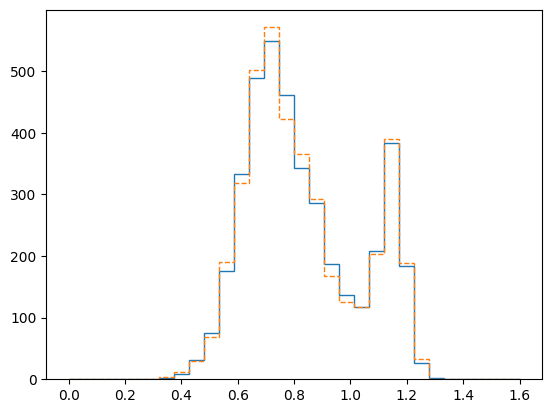

In [53]:
# create random samples from true P(color | M*) use the inverse CDF trick + interpolation
# for CAM
true_color = hydro_mstar_cut["color"]
true_color_sorted = np.sort(true_color)
n_samples = len(true_color_sorted)
u = np.random.uniform(size=(n_samples,))
color_ranks = rankdata(true_color_sorted, axis=0, method="ordinal")
color_u = (color_ranks - 1) / len(color_ranks)
color_samples = np.interp(u, color_u, true_color_sorted)

bins = np.linspace(0.0, 1.6, 31)


plt.hist(true_color, bins=bins, histtype="step")
plt.hist(color_samples, bins=bins, histtype="step", ls="--")

In [54]:
# CAM prediction

sham_mask = (logmstar_sham > 9.5) & (logmstar_sham < 10.2)
hydro_cam = hydro_full[sham_mask]

color_cam_pred = qt(hydro_cam["z12"].data, color_samples)
color_cam_pred.shape

(4001,)

In [55]:
# MultiCAM prediction for color based on a_n
# ns = np.linspace(0, 1, n_fracs)
ns = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
an = get_an_from_mpeak_mah(hydro_full["mpeak_mah"].data, scales=scales, ns=ns)
an.shape

(11310, 9)

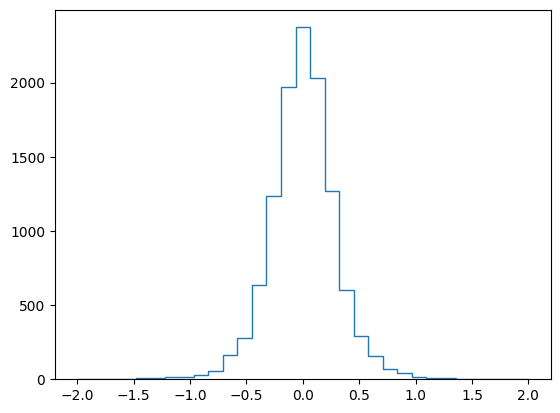

In [56]:
# deviations
star_devs = log10_stellar_mass - logmstar_sham
plt.hist(star_devs, bins=31, histtype="step", range=(-2, 2));

In [57]:
x = an
y1 = hydro_full["color"].reshape(-1, 1)
y2 = star_devs.reshape(-1, 1)
y = np.concatenate([y1, y2], axis=1)
x.shape, y.shape

((11310, 9), (11310, 2))

In [58]:
model = MultiCamSampling(ns.shape[0], 2)
model.fit(x, y)
y_pred = model.sample(x)

color_pred = y_pred[:, 0]
star_devs_pred = y_pred[:, 1]

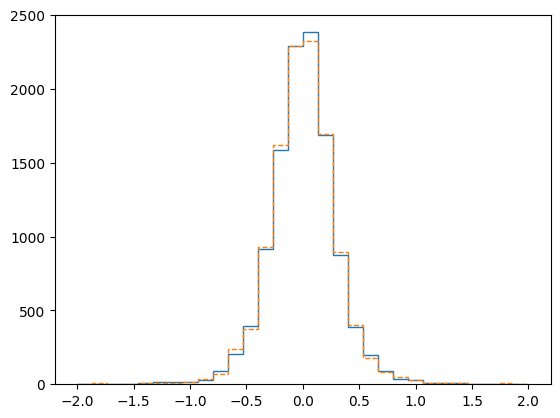

In [59]:
bins = np.linspace(-2, 2, 31)
plt.hist(star_devs, bins=bins, histtype="step", range=(-2, 2))
plt.hist(star_devs_pred, bins=bins, histtype="step", range=(-2, 2), ls="--");

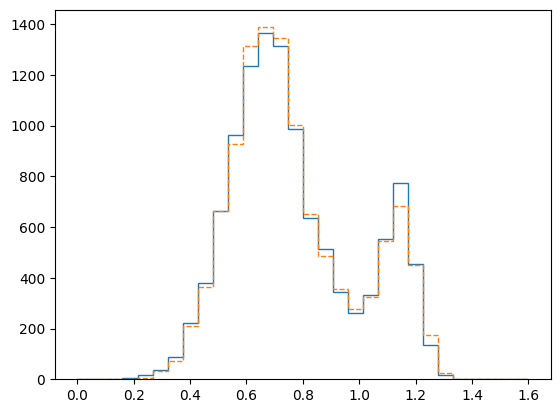

In [60]:
bins = np.linspace(0.0, 1.6, 31)
plt.hist(hydro_full["color"], bins=bins, histtype="step")
plt.hist(color_pred, bins=bins, histtype="step", ls="--");

In [63]:
log_mstar_pred = star_devs_pred + logmstar_sham
sham_mask = (log_mstar_pred > 9.5) & (log_mstar_pred < 10.2)
hydro_mstar_pred = hydro_full[sham_mask]
hydro_mstar_pred["pred_color"] = color_pred[sham_mask]

len(hydro_mstar_cut), len(hydro_mstar_pred)


(4001, 3972)

(array([  0.,   3.,   3.,  11.,  14.,  24.,  51.,  62.,  87., 159., 181.,
        205., 269., 281., 315., 306., 254., 220., 178., 137.,  98., 107.,
         85.,  59.,  52.,  49., 101., 118., 142., 171., 118.,  68.,  34.,
          8.,   1.,   0.,   0.,   0.,   0.,   0.]),
 array([0.2   , 0.2325, 0.265 , 0.2975, 0.33  , 0.3625, 0.395 , 0.4275,
        0.46  , 0.4925, 0.525 , 0.5575, 0.59  , 0.6225, 0.655 , 0.6875,
        0.72  , 0.7525, 0.785 , 0.8175, 0.85  , 0.8825, 0.915 , 0.9475,
        0.98  , 1.0125, 1.045 , 1.0775, 1.11  , 1.1425, 1.175 , 1.2075,
        1.24  , 1.2725, 1.305 , 1.3375, 1.37  , 1.4025, 1.435 , 1.4675,
        1.5   ]),
 [<matplotlib.patches.Polygon at 0x11ad80190>])

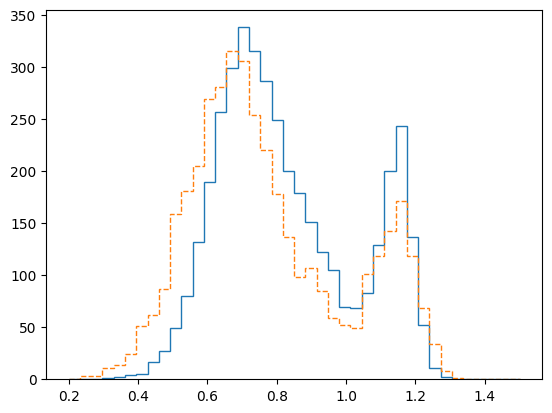

In [64]:
bins = np.linspace(0.2, 1.5, 41)


plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step", ls="-")
plt.hist(hydro_mstar_pred["pred_color"], bins=bins, histtype="step", ls="--")

## Clustering Results

In [65]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)
randoms.shape

(50000, 3)

In [66]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]

pred_color = hydro_mstar_pred["pred_color"]
multicam_red = hydro_mstar_pred[pred_color > COLOR_CUT]
multicam_blue = hydro_mstar_pred[pred_color <= COLOR_CUT]


cam_red = hydro_cam[color_cam_pred > COLOR_CUT]
cam_blue = hydro_cam[color_cam_pred <= COLOR_CUT]

In [67]:
(
    len(red_true),
    len(cam_red),
    len(multicam_red),
    len(blue_true),
    len(cam_blue),
    len(multicam_blue),
)

(954, 959, 833, 3047, 3042, 3139)

In [68]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [69]:
xyz_red = return_xyz_formatted_array(
    cam_red["x"].data, cam_red["y"].data, cam_red["z"].data
)
xyz_blue = return_xyz_formatted_array(
    cam_blue["x"].data, cam_blue["y"].data, cam_blue["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [70]:
xyz_red = return_xyz_formatted_array(
    multicam_red["x"].data,
    multicam_red["y"].data,
    multicam_red["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue["x"].data,
    multicam_blue["y"].data,
    multicam_blue["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


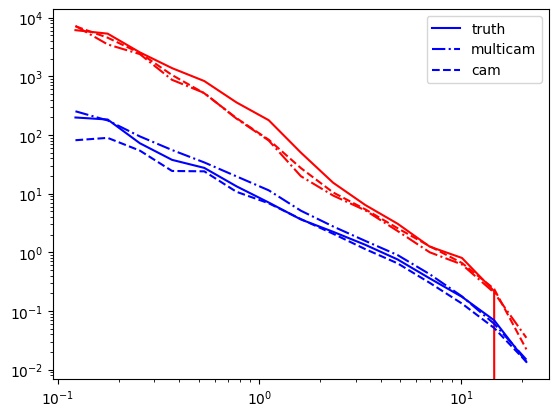

In [71]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.legend()

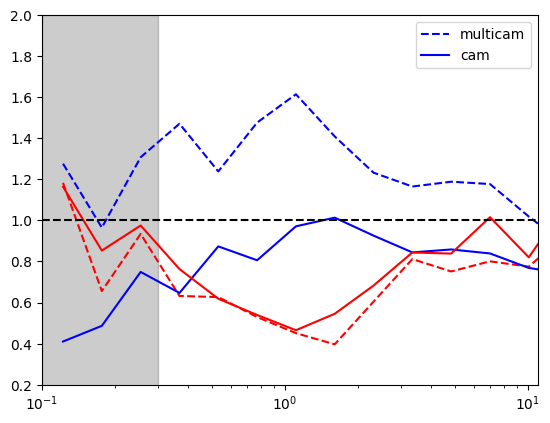

In [72]:
plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# plt.axvline(0.3, c="k")
plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)
# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output